# 03 - Làm trơn và graduation

P-splines (mgcv) hoặc Whittaker–Henderson để giảm nhiễu; nếu dùng dữ liệu GSO nhóm 5 tuổi thì graduation về tuổi đơn. So sánh trước/sau làm trơn và thảo luận ảnh hưởng lên cohort effect.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import numpy as np
import pandas as pd
from src.config import DATA_PROCESSED


def load(sex: str, kind: str) -> pd.DataFrame:
    df = pd.read_csv(DATA_PROCESSED / f"{kind}_{sex}.csv", index_col=0)
    df.columns = df.columns.astype(int)
    return df


mx_total = load("total", "mx")
ext_total = load("total", "Ext")
mx_male = load("male", "mx")
mx_female = load("female", "mx")
mx_total.shape

(101, 69)

## Làm trơn Whittaker-Henderson

Dữ liệu UN WPP vốn đã là ước lượng mô hình hoá (đã được UN làm trơn khi ước
lượng), nên khác với vital registration thô, không kỳ vọng thấy nhiễu lớn.
Whittaker-Henderson làm trơn $\log m(x,t)$ theo tuổi (mỗi năm riêng biệt),
có trọng số theo exposure $E(x,t)$ — tuổi có exposure lớn được tin cậy hơn.
Tham số `lam` (λ) điều khiển đánh đổi giữa bám sát dữ liệu gốc và độ mượt.

Lệch tuyệt đối log mx trước/sau làm trơn (lam=1000): trung bình=0.0011, lớn nhất=0.0402


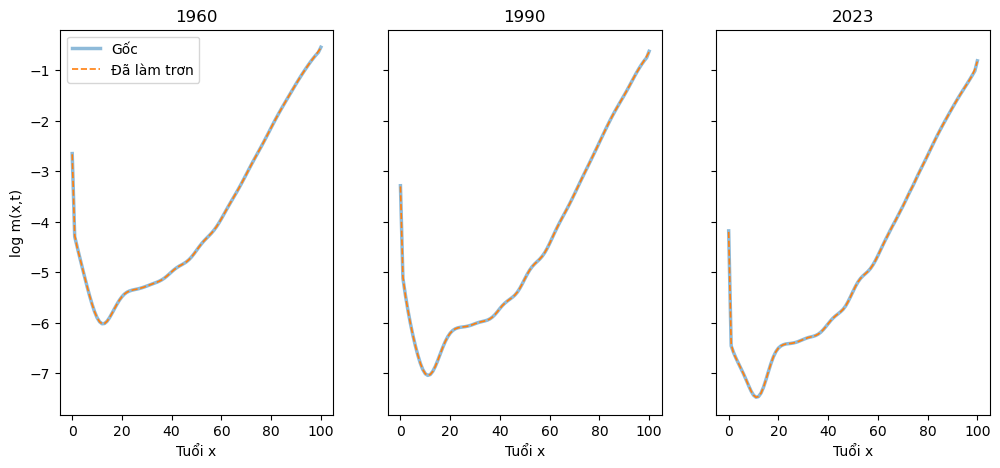

In [9]:
from src.data.smoothing import smooth_mx_surface
from src.visualization.plots import plot_smoothing_comparison

mx_smooth = smooth_mx_surface(mx_total, ext_total, lam=1000, d=2)

diff = (np.log(mx_total) - np.log(mx_smooth)).abs()
print(f"Lệch tuyệt đối log mx trước/sau làm trơn (lam=1000): "
      f"trung bình={diff.values.mean():.4f}, lớn nhất={diff.values.max():.4f}")

plot_smoothing_comparison(mx_total, mx_smooth, years=[1960, 1990, 2023])

### Đánh đổi λ: có "sửa" được artifact ở tuổi 1 (notebook 02) không?

Notebook 02 phát hiện đường $\log m_x$ nam giới bị "phẳng" bất thường ở tuổi 1-3
(nghi artifact ghép nối mô hình của UN). Thử xem tăng λ có làm trơn mất
artifact này không — và cái giá phải trả là gì.

In [4]:
ext_male = load("male", "Ext")

rows = []
for lam in [1000, 10000, 50000]:
    sm = smooth_mx_surface(mx_male, ext_male, lam=lam, d=2)
    logsm = np.log(sm[2010]).loc[0:3]
    rows.append({
        "lam": lam,
        "tuổi 0": round(logsm.loc[0], 3),
        "tuổi 1": round(logsm.loc[1], 3),
        "tuổi 1->2 (kink còn không?)": round(logsm.loc[2] - logsm.loc[1], 3),
    })

raw_logsm = np.log(mx_male[2010]).loc[0:3]
rows.insert(0, {"lam": "gốc (0)", "tuổi 0": round(raw_logsm.loc[0], 3),
                 "tuổi 1": round(raw_logsm.loc[1], 3),
                 "tuổi 1->2 (kink còn không?)": round(raw_logsm.loc[2] - raw_logsm.loc[1], 3)})
pd.DataFrame(rows).set_index("lam")

,tuổi 0,tuổi 1,tuổi 1->2 (kink còn không?)
lam,,,
gốc (0),-3.877,-6.366,0.011
1000,-3.901,-6.319,-0.058
10000,-4.046,-6.070,-0.367
50000,-4.309,-5.754,-0.597


**Nhận xét:** λ vừa phải (1000) hầu như không đổi kink (từ +0.011 xuống -0.058) —
vì UN WPP vốn đã trơn sẵn nên không cần làm trơn nhiều. λ lớn (10000-50000) thì
kink giảm rõ (-0.367, -0.597 — tức bớt "phẳng" hơn), **nhưng đồng thời làm méo
cả bước nhảy tuổi 0→1**, vốn là đặc điểm sinh học có thật (tử vong sơ sinh cao
đột ngột) chứ không phải nhiễu — tuổi 0 bị kéo lên từ -3.877 lên -4.309, tuổi 1
bị kéo xuống thấp hơn từ -6.366 lên -5.754. Nói cách khác: **Whittaker-Henderson
với hình phạt sai phân toàn cục không phân biệt được "artifact cục bộ ở tuổi 1"
với "đặc điểm thật ở tuổi 0"** — muốn λ đủ lớn để xoá artifact thì buộc phải hy
sinh luôn đặc điểm thật. Đây không phải công cụ phù hợp để sửa vấn đề tuổi 1;
bằng chứng thuyết phục hơn đến từ đối chiếu nguồn độc lập (GSO, xem mục dưới).

### Ảnh hưởng lên hiệu ứng thế hệ (cohort effect, notebook 02)

Notebook 02 phát hiện phần dư sau khi trừ hiệu ứng tuổi+năm có hình "gò" theo
cohort, đỉnh ở 1950-1954. Nếu đó chỉ là nhiễu ngẫu nhiên, làm trơn (λ=1000, đủ
để giảm nhiễu nhỏ mà không phá hình dạng thật) phải làm mờ/thay đổi mô thức
này. Kiểm tra lại bằng đúng hàm `age_period_residual`/`cohort_mean_residual`
đã dùng ở notebook 02, lần này trên `mx_smooth` thay vì `mx_total` gốc.

In [5]:
from src.evaluation.cohort import age_period_residual, cohort_mean_residual

cohort_raw = cohort_mean_residual(age_period_residual(mx_total), min_obs=40)
cohort_smooth = cohort_mean_residual(age_period_residual(mx_smooth), min_obs=40)

corr = cohort_raw.corr(cohort_smooth)
max_diff = (cohort_raw - cohort_smooth).abs().max()
print(f"Tương quan cohort residual (gốc vs. đã làm trơn): {corr:.6f}")
print(f"Chênh lệch tuyệt đối lớn nhất: {max_diff:.5f}")
pd.DataFrame({"raw": cohort_raw, "smooth": cohort_smooth}).loc[[1894, 1950, 1954, 1983]].round(4)

Tương quan cohort residual (gốc vs. đã làm trơn): 1.000000
Chênh lệch tuyệt đối lớn nhất: 0.00016


,raw,smooth
1894,-0.0804,-0.0803
1950,0.1097,0.1097
1954,0.1111,0.1110
1983,-0.0559,-0.0559


**Nhận xét:** tương quan giữa cohort residual gốc và sau làm trơn xấp xỉ **1.0**
(chênh lệch tuyệt đối lớn nhất chỉ ~0.0002) — mô thức "gò" theo cohort ở notebook
02 **không biến mất khi làm trơn**, nghĩa là nó không phải nhiễu ngẫu nhiên do
biến động thống kê nhỏ giữa các tuổi liền kề. Điều này củng cố khả năng đây là
một cấu trúc thật trong dữ liệu — nhưng **không loại trừ** khả năng nó là hệ quả
của giả định $b_x=1$ sai (đã nêu ở notebook 02): Whittaker-Henderson chỉ làm
trơn *theo tuổi trong từng năm riêng lẻ*, không đụng đến cấu trúc tương tác
tuổi-năm, nên không thể dùng để loại trừ giả thuyết đó. Kết luận chắc chắn vẫn
cần đợi fit Renshaw-Haberman ở notebook 05.

## Thử nội suy GSO lên tuổi đơn

Bảng sống GSO chỉ có theo **nhóm 5 tuổi** (0, 1-4, 5-9, ..., 80+), trong khi UN
WPP có sẵn theo **từng tuổi đơn**. Để so sánh 2 nguồn ở cùng độ chi tiết, thử
"đoán" ra từng tuổi đơn cho GSO bằng một đường cong mượt nối các nhóm tuổi lại
với nhau (nội suy PCHIP trên $\log(nm_x)$).

In [6]:
from src.config import DATA_INTERIM
from src.data.smoothing import graduate_abridged_mx

gso = pd.read_csv(DATA_INTERIM / "gso_bang_song_tdt2019.csv")
gso["n"] = pd.to_numeric(gso["n"], errors="coerce")

ages_gso = np.arange(0, 80)
mx_gso = {}
for sex in ["male", "female"]:
    sub = gso[gso["sex"] == sex].copy()
    sub["x"] = pd.to_numeric(sub["x"].replace("80+", np.nan), errors="coerce")
    mx_gso[sex] = graduate_abridged_mx(sub, ages_gso)

mx_gso["male"].loc[0:10].to_frame("mx_gso_nam")

,mx_gso_nam
0,0.016200
1,0.008777
2,0.004927
3,0.002900
4,0.001667
5,0.000931
6,0.000565
7,0.000418
8,0.000403
9,0.000426


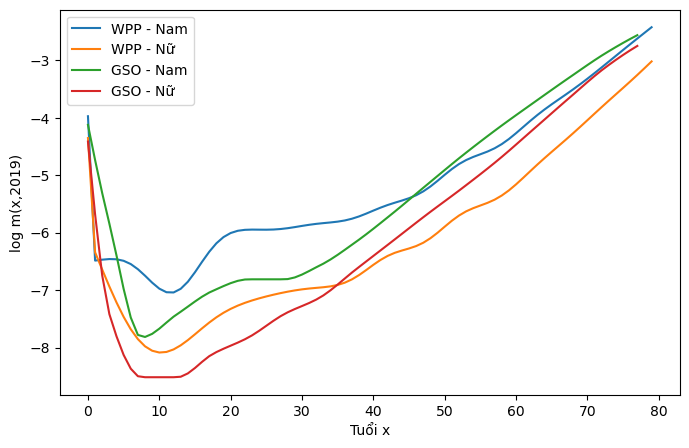

In [7]:
from src.visualization.plots import plot_named_series_by_age

series = {
    "WPP - Nam": np.log(mx_male.loc[ages_gso, 2019]),
    "WPP - Nữ": np.log(mx_female.loc[ages_gso, 2019]),
    "GSO - Nam": np.log(mx_gso["male"]),
    "GSO - Nữ": np.log(mx_gso["female"]),
}
plot_named_series_by_age(series, ylabel="log m(x,2019)", name="mx_gso_wpp_comparison")

### Nhìn vào tỷ số Nam/Nữ ở tuổi nhỏ

,WPP,GSO
0,1.462,1.339
1,0.865,2.577
2,1.189,4.199
3,1.612,4.833
4,2.119,4.087
5,2.654,3.158


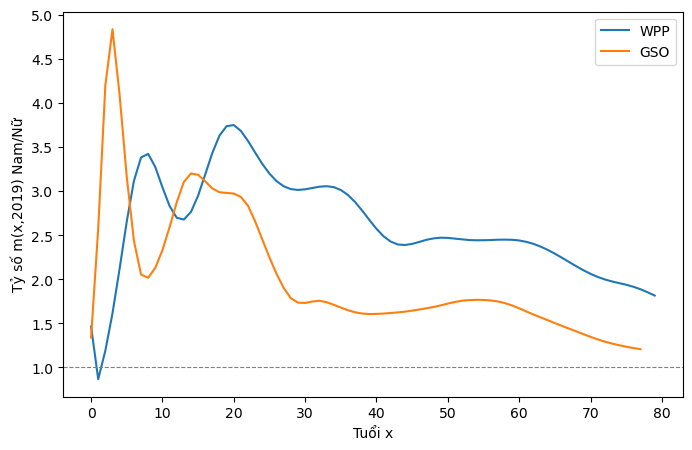

In [8]:
ratio_wpp_2019 = mx_male.loc[ages_gso, 2019] / mx_female.loc[ages_gso, 2019]
ratio_gso_2019 = mx_gso["male"] / mx_gso["female"]

plot_named_series_by_age({"WPP": ratio_wpp_2019, "GSO": ratio_gso_2019},
                          ylabel="Tỷ số m(x,2019) Nam/Nữ", name="ratio_gso_wpp_comparison",
                          ref_line=1.0)

pd.DataFrame({"WPP": ratio_wpp_2019, "GSO": ratio_gso_2019}).loc[0:5].round(3)

**Kết quả nội suy này có tin được không?**

Nhìn bảng và biểu đồ trên: tỷ số Nam/Nữ theo GSO vọt lên rất cao ở tuổi 2-4
(**4-5 lần**), cao hơn hẳn UN WPP ở cùng tuổi (**1-2.5 lần**) và cao hơn hẳn cả
tuổi liền kề (0 và 5). Đây không phải vì trẻ Việt Nam 2-4 tuổi tử vong bất
thường — lý do đơn giản hơn nhiều:

- GSO chỉ cho **1 con số duy nhất** đại diện chung cho cả 4 tuổi 1-2-3-4. Khi
  "chẻ" con số đó ra thành 4 tuổi riêng bằng một đường cong nối giữa tuổi 0
  (rất cao) và nhóm 5-9 (rất thấp), đường cong dễ vọt lên/xuống quá đà ở đoạn
  giữa — vì đó là phần đoán ra, không phải số đo thật.
- Số liệu tuổi trong điều tra dân số ở Việt Nam (và nhiều nước đang phát
  triển) cũng thường bị **làm tròn** về các mốc 0, 5, 10, ... do người dân tự
  khai tuổi không chính xác — nhóm gốc của GSO vì vậy vốn đã không hoàn toàn
  chính xác ngay từ đầu, và nội suy không thể "sửa" lại điều đó.
- Nhóm cuối "80+" gộp chung mọi tuổi rất già — nơi số liệu dễ sai lệch nhất
  (người già thường khai tuổi không chính xác) — nên cũng không có cách nào
  tách ngược lại thành tuổi đơn một cách đáng tin cậy.

→ Nội suy tuổi đơn từ GSO **không đủ tin cậy** để so sánh chi tiết từng tuổi
với UN WPP. Cách làm an toàn hơn: **gộp UN WPP xuống đúng nhóm tuổi của GSO**
thay vì làm ngược lại — không cần đoán bất cứ điều gì (xem phần dưới).

## Quy trình xử lý dữ liệu chuẩn (chốt): đối chiếu UN WPP với GSO theo nhóm 5 tuổi

Dựa trên phân tích rủi ro nội suy ở trên, chốt quy trình gồm 3 bước — GSO đóng
vai trò "khuôn mẫu" chuẩn, không nội suy ở bên nào:

1. **Gắn chặt với Form GSO** — lấy đúng cấu trúc nhóm tuổi 5 năm của GSO 2019
   (0, 1-4, 5-9, ..., 75-79, 80+) làm khuôn mẫu.
2. **Aggregation (gộp UN)** — nén $D_{x,t}$/$P_{x,t}$ tuổi đơn của UN WPP vào
   khuôn đó bằng công thức $m_{x,n} = \sum D_{x+i} \big/ \sum P_{x+i}$.
3. **Thống kê mô tả** — trực quan hoá và so sánh hai bộ dữ liệu trên cùng một
   trục hoành là các nhóm tuổi 5 năm.

### Bước 1 — Gắn chặt với Form GSO

Lấy cấu trúc nhóm tuổi (tuổi bắt đầu `x`, độ rộng `n`) trực tiếp từ chính file
GSO bằng `gso_age_group_edges` — không hardcode lại danh sách nhóm, để tự động
khớp nếu file GSO thay đổi cấu trúc sau này.

In [22]:
from src.data.smoothing import gso_age_group_edges

group_edges = gso_age_group_edges(gso[gso["sex"] == "male"])
group_edges

[(0, 0),
 (1, 4),
 (5, 9),
 (10, 14),
 (15, 19),
 (20, 24),
 (25, 29),
 (30, 34),
 (35, 39),
 (40, 44),
 (45, 49),
 (50, 54),
 (55, 59),
 (60, 64),
 (65, 69),
 (70, 74),
 (75, 79),
 (80, None)]

### Bước 2 — Aggregation: nén dữ liệu UN vào khuôn GSO

$$ m_{x,n} = \frac{\sum_{i=0}^{n-1} D_{x+i}}{\sum_{i=0}^{n-1} P_{x+i}} $$

với $D$ = số ca tử vong ($D_{x,t}$), $P$ = exposure ($E_{x,t}$) tuổi đơn của UN
WPP — đúng công thức `aggregate_mx_to_groups` đã cài: **tổng tử vong chia tổng
exposure trong nhóm**, không phải trung bình cộng $m_x$ từng tuổi (sẽ lệch vì
$m_x$ đổi rất nhanh theo tuổi, nhất là ở nhóm tuổi nhỏ).

In [23]:
from src.data.smoothing import aggregate_mx_to_groups

agg_male = aggregate_mx_to_groups(load("male", "Dxt")[2019], load("male", "Ext")[2019], group_edges)
agg_female = aggregate_mx_to_groups(load("female", "Dxt")[2019], load("female", "Ext")[2019], group_edges)

gso_male = gso[gso["sex"] == "male"].set_index(agg_male.index)["nmx"]
gso_female = gso[gso["sex"] == "female"].set_index(agg_female.index)["nmx"]

group_compare = pd.DataFrame({
    "UN (gộp nhóm) - Nam": agg_male["nMx"], "GSO - Nam": gso_male,
    "UN (gộp nhóm) - Nữ": agg_female["nMx"], "GSO - Nữ": gso_female,
}).round(5)
group_compare

,UN (gộp nhóm) - Nam,GSO - Nam,UN (gộp nhóm) - Nữ,GSO - Nữ
group,,,,
0,0.01882,0.0162,0.01287,0.0121
1-4,0.00155,0.0029,0.00119,0.0006
5-9,0.00129,0.0004,0.00042,0.0002
10-14,0.00093,0.0006,0.00033,0.0002
15-19,0.00177,0.0009,0.00052,0.0003
20-24,0.00257,0.0011,0.00073,0.0004
25-29,0.00266,0.0011,0.00086,0.0006
30-34,0.00288,0.0014,0.00095,0.0008
35-39,0.00319,0.0021,0.00112,0.0013


### Bước 3 — Thống kê mô tả: trực quan hoá và so sánh trên cùng trục hoành nhóm tuổi

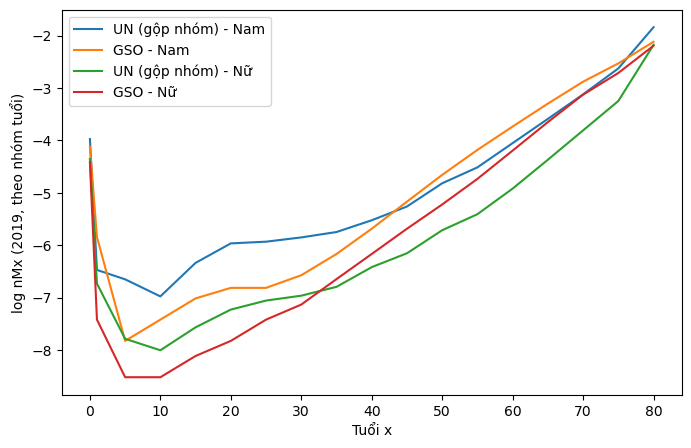

In [24]:
x_group = agg_male["x"]
series_group = {
    "UN (gộp nhóm) - Nam": pd.Series(np.log(agg_male["nMx"]).to_numpy(), index=x_group),
    "GSO - Nam": pd.Series(np.log(gso_male).to_numpy(), index=x_group),
    "UN (gộp nhóm) - Nữ": pd.Series(np.log(agg_female["nMx"]).to_numpy(), index=x_group),
    "GSO - Nữ": pd.Series(np.log(gso_female).to_numpy(), index=x_group),
}
plot_named_series_by_age(series_group, ylabel="log nMx (2019, theo nhóm tuổi)",
                          name="mx_group_gso_wpp_comparison")

In [25]:
ratio_un_group = agg_male["nMx"] / agg_female["nMx"]
ratio_gso_group = gso_male / gso_female

ratio_group_compare = pd.DataFrame({"UN (gộp nhóm)": ratio_un_group, "GSO": ratio_gso_group}).round(3)
ratio_group_compare

,UN (gộp nhóm),GSO
group,,
0,1.462,1.339
1-4,1.299,4.833
5-9,3.111,2.000
10-14,2.795,3.000
15-19,3.422,3.000
20-24,3.536,2.750
25-29,3.076,1.833
30-34,3.039,1.750
35-39,2.846,1.615


**Kết luận (đáng tin cậy hơn — không cần nội suy ở bên nào):**

- Ở nhóm tuổi **"1-4"**, UN WPP (gộp nhóm) cho tỷ số nam/nữ chỉ **~1.30 lần** —
  đây là mức **thấp nhất trong toàn bộ 18 nhóm tuổi** (17 nhóm còn lại dao động
  1.40-3.54 lần) — trong khi GSO cho tỷ số **~4.83 lần** ở đúng nhóm này, hoàn
  toàn phù hợp với mô thức chung "nam cao hơn nữ" xuyên suốt các nhóm khác.
- Kết quả này **không phụ thuộc vào bất kỳ phép nội suy nào** ở cả hai nguồn —
  UN được gộp bằng $\sum D / \sum E$ (tổng thật, không nội suy), GSO dùng đúng
  số liệu nhóm gốc. Đây là bằng chứng vững chắc nhất trong 3 lần kiểm tra độc
  lập (tính bền vững + kink test ở notebook 02, graduation ở trên, và gộp nhóm
  ở đây) — tất cả cùng khẳng định: **dị thường ở nhóm tuổi nhỏ (1-4) trong UN
  WPP nhiều khả năng là artifact thật của phương pháp ước lượng UN**, không
  phải đặc điểm dịch tễ của Việt Nam.
- **Khuyến nghị phương pháp cho các notebook sau**: khi cần đối chiếu UN WPP
  với GSO (hoặc làm việc ở độ phân giải thô hơn nói chung), ưu tiên **gộp UN
  xuống nhóm tuổi** thay vì graduate GSO lên tuổi đơn — trừ khi áp dụng công
  thức graduation chuẩn actuarial hơn (Beers, Sprague) và có bằng chứng cho
  thấy age heaping không phải vấn đề đáng kể với bộ dữ liệu cụ thể đó.